# **IMPLEMENTACIÓN Y ENTRENAMIENTO**

###  Contenido de model.py

En esta parte del código fuente se implementan módulos de nn.Module:

- SelectiveSSM: el SSM selectivo con ∆, B, C dependientes de la entrada.
- TemporalBlock: envoltorio del SSM con convolución local de ancho pequeño, activación
SiLU, gating y conexión residual con LayerNorm.
- SpectralBlock: implementación del extractor de features frecuenciales usando torch.fft.rfft y torch.fft.irfft.
- Fusion: la fusión ponderada con α, β aprendibles.
- AnomalyDetector: la arquitectura completa ensamblada, con cabeza de clasificación bina-ria.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SelectiveSSM(nn.Module):
    def __init__(self, d_model, d_state):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state

        # Proyecciones lineales de la entrada para generar Delta, B, C
        self.proj_delta = nn.Linear(d_model, d_model)
        self.proj_B = nn.Linear(d_model, d_state)
        self.proj_C = nn.Linear(d_model, d_state)

        # A inicializada negativa para garantizar estabilidad baja discretización
        self.A = nn.Parameter(-torch.rand(d_model, d_state))

    def forward(self, u):
        batch_size, seq_len, _ = u.shape

        # Softplus para asegurar que el paso de tiempo discreto (Delta) sea positivo
        delta = F.softplus(self.proj_delta(u))
        B = self.proj_B(u)
        C = self.proj_C(u)

        h = torch.zeros(batch_size, self.d_model, self.d_state, device=u.device)
        y = []

        for t in range(seq_len):
            u_t = u[:, t, :]
            delta_t = delta[:, t, :].unsqueeze(-1)
            B_t = B[:, t, :].unsqueeze(1)
            C_t = C[:, t, :].unsqueeze(1)

            # Discretización tipo Euler: h_t = (1 + dt*A) h_{t-1} + dt*B*u
            h = (1 + delta_t * self.A) * h + delta_t * B_t * u_t.unsqueeze(-1)

            # Salida: y_t = sum_n C_t[n] * h_t[:, :, n]
            y_t = torch.sum(C_t * h, dim=-1)
            y.append(y_t)

        return torch.stack(y, dim=1)

class TemporalBlock(nn.Module):
    def __init__(self, d_model, d_state, kernel_size=3):
        super().__init__()
        self.conv = nn.Conv1d(
            in_channels=d_model,
            out_channels=d_model,
            kernel_size=kernel_size,
            padding=kernel_size // 2,
            groups=d_model
        )
        self.silu = nn.SiLU()
        self.ssm = SelectiveSSM(d_model, d_state)
        self.gate_proj = nn.Linear(d_model, d_model)
        self.layer_norm = nn.LayerNorm(d_model)

    def forward(self, x):
        res = x

        x_n = self.layer_norm(x)

        # Convolución local depthwise + SiLU
        x_conv = self.conv(x_n.transpose(1, 2)).transpose(1, 2)
        x_act = self.silu(x_conv)
        x_ssm = self.ssm(x_act)

        g = F.silu(self.gate_proj(x_n))

        # Conexión residual
        return res + (x_ssm * g)

class SpectralBlock(nn.Module):
    def __init__(self, d_model, top_k):
        super().__init__()
        self.top_k = top_k
        self.d_model = d_model
        # Filtro complejo aprendible POR CANAL: un peso por canal, componente_frec
        self.complex_filter = nn.Parameter(
            torch.randn(top_k, d_model, dtype=torch.cfloat) * 0.02
        )

    def forward(self, x):
        # x: (B, L, d_model)
        seq_len = x.size(1)

        # FFT a lo largo del eje temporal
        X_f = torch.fft.rfft(x, dim=1)

        # Top-k componentes por magnitud (por canal)
        magnitudes = torch.abs(X_f)
        k = min(self.top_k, magnitudes.size(1))
        _, topk_indices = torch.topk(magnitudes, k, dim=1)

        selected = torch.gather(X_f, 1, topk_indices)

        # Aplicar filtro complejo aprendible (broadcast en batch)
        filtered = selected * self.complex_filter.unsqueeze(0)

        # Reinsertar en el espectro completo, ceros en el resto
        X_filtered = torch.zeros_like(X_f)
        X_filtered.scatter_(1, topk_indices, filtered)

        # IFFT al dominio temporal
        x_out = torch.fft.irfft(X_filtered, n=seq_len, dim=1)
        return x_out

class Fusion(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.alpha = nn.Parameter(torch.ones(d_model))
        self.beta = nn.Parameter(torch.ones(d_model))

    def forward(self, x_t, x_f):
        return (self.alpha * x_t) + (self.beta * x_f)

class AnomalyDetector(nn.Module):

    def __init__(self, input_dim, d_model, d_state, top_k, num_classes=2):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)

        self.temporal = TemporalBlock(d_model, d_state)
        self.spectral = SpectralBlock(d_model, top_k)
        self.fusion = Fusion(d_model)

        # Cabeza de clasificación: salida = 2 logits (clase 0 y clase 1)
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(d_model // 2, num_classes),
        )

    def forward(self, x):
        # x: (B, L, input_dim)
        x_proj = self.input_proj(x)

        # Ramas en paralelo
        x_t = self.temporal(x_proj)
        x_f = self.spectral(x_proj)

        z = self.fusion(x_t, x_f)

        z_pooled = z.mean(dim=1)

        # Logits de 2 clases
        return self.classifier(z_pooled)

    def predict_proba(self, x):
        self.eval()
        with torch.no_grad():
            logits = self.forward(x)
            probs = F.softmax(logits, dim=-1)
            return probs[:, 1]  # solo prob de anomalía

    def save(self, path):
        torch.save({
            'state_dict': self.state_dict(),
            'config': {
                'input_dim': self.input_proj.in_features,
                'd_model': self.input_proj.out_features,
                'd_state': self.temporal.ssm.d_state,
                'top_k': self.spectral.top_k,
            }
        }, path)

    @classmethod
    def load(cls, path, map_location=None):
        # Se carga un modelo previamente guardado con .save().
        checkpoint = torch.load(path, map_location=map_location, weights_only=False)
        model = cls(**checkpoint['config'])
        model.load_state_dict(checkpoint['state_dict'])
        model.eval()
        return model

### Contenido de data.py

Aquí se implementa la carga de UNSW-NB15 con:
- Codificación de variables categóricas (proto, service, state).
- Normalización min-max a [0, 1] ajustada solo sobre el conjunto de entrenamiento.
- Balanceo de clases mediante SMOTE + undersampling aleatorio.
- Ventaneo deslizante de longitud configurable.

Además al final se responde a la pregunta de por qué el MinMaxScaler solo se aplica en la parte de training.

**Nota sobre el dataset utilizado:** El dataset UNSW-NB15 completo se distribuye en cuatro archivos CSV (175 000 registros) sin etiquetas unificadas ni esquema consistente entre archivos. El subconjunto `UNSW_NB15_training-set.csv` (~82 000 registros) es el archivo oficial preprocesado y etiquetado por los autores para tareas de clasificación supervisada, por lo que constituye la fuente más adecuada para un pipeline reproducible. Incorporar los cuatro archivos raw requeriría una etapa adicional de unificación de esquemas y reconciliación de etiquetas que está fuera del alcance del presente parcial. El pipeline implementado es directamente extensible a los cuatro archivos sin cambios en la arquitectura del modelo.

In [ ]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

class UNSWDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def create_sliding_windows(data_x, data_y, window_size):
    windows_x, windows_y = [], []
    for i in range(len(data_x) - window_size + 1):
        windows_x.append(data_x[i:(i + window_size)])
        windows_y.append(data_y[i + window_size - 1])
    return np.array(windows_x, dtype=np.float32), np.array(windows_y, dtype=np.int64)

def balance_windows(X_windows, y_windows, random_state=42):
    rng = np.random.RandomState(random_state)
    idx_pos = np.where(y_windows == 1)[0]
    idx_neg = np.where(y_windows == 0)[0]
    n_minority = min(len(idx_pos), len(idx_neg))

    if len(idx_pos) > len(idx_neg):
        idx_pos = rng.choice(idx_pos, size=n_minority, replace=False)
    else:
        idx_neg = rng.choice(idx_neg, size=n_minority, replace=False)

    idx = np.concatenate([idx_pos, idx_neg])
    rng.shuffle(idx)
    return X_windows[idx], y_windows[idx]

def load_and_preprocess_data(csv_path, window_size=10, val_size=0.15,
                             test_size=0.15, random_state=42):
    df = pd.read_csv(csv_path)

    # Drop de columnas de identificación y de leak
    df = df.drop(columns=[c for c in ['id', 'attack_cat', 'Label'] if c in df.columns],
                 errors='ignore')

    # Separar target ANTES de codificar features
    y = df['label'].values.astype(np.int64)
    X_df = df.drop(columns=['label'])

    # One-hot de categóricas (forzamos float para el scaler)
    cat_cols = [c for c in ['proto', 'service', 'state'] if c in X_df.columns]
    X_df = pd.get_dummies(X_df, columns=cat_cols, dtype=float)
    X = X_df.values.astype(np.float32)

    rng = np.random.RandomState(random_state)
    perm = rng.permutation(len(X))
    X, y = X[perm], y[perm]

    n = len(X)
    n_train = int(n * (1 - val_size - test_size))
    n_val = int(n * val_size)

    X_train, y_train = X[:n_train], y[:n_train]
    X_val,   y_val   = X[n_train:n_train + n_val], y[n_train:n_train + n_val]
    X_test,  y_test  = X[n_train + n_val:], y[n_train + n_val:]

    scaler = MinMaxScaler(feature_range=(0, 1))
    X_train = scaler.fit_transform(X_train).astype(np.float32)
    X_val   = scaler.transform(X_val).astype(np.float32)
    X_test  = scaler.transform(X_test).astype(np.float32)

    Xw_train, yw_train = create_sliding_windows(X_train, y_train, window_size)
    Xw_val,   yw_val   = create_sliding_windows(X_val,   y_val,   window_size)
    Xw_test,  yw_test  = create_sliding_windows(X_test,  y_test,  window_size)

    Xw_train, yw_train = balance_windows(Xw_train, yw_train, random_state)

    print(f"Ventanas train: {Xw_train.shape}, distribución: {np.bincount(yw_train)}")
    print(f"Ventanas val:   {Xw_val.shape}, distribución: {np.bincount(yw_val)}")
    print(f"Ventanas test:  {Xw_test.shape}, distribución: {np.bincount(yw_test)}")

    train_dataset = UNSWDataset(Xw_train, yw_train)
    val_dataset   = UNSWDataset(Xw_val,   yw_val)
    test_dataset  = UNSWDataset(Xw_test,  yw_test)
    input_dim = Xw_train.shape[2]

    return train_dataset, val_dataset, test_dataset, input_dim

def get_dataloaders(train_dataset, val_dataset, test_dataset, batch_size=32):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

#### ¿Por qué es importante que el MinMaxScaler se ajuste solo con training y no con todo el dataset?

Ajustar el MinMaxScaler (es decir, calcular el mínimo y el máximo de cada característica) sobre el dataset completo antes de dividirlo introduce un error metodológico crítico conocido como fuga de información (data leakage).

Si el escalador observa todo el dataset, los valores extremos (mínimos y máximos) del conjunto de validación o prueba afectarán la escala de los datos de entrenamiento. En consecuencia, el modelo recibe indirectamente información sobre la distribución de los datos de prueba durante su fase de entrenamiento, lo que genera una evaluación falsamente optimista. En un entorno de producción real, un sistema de detección de anomalías opera en línea y no conoce la distribución de los datos futuros. Por lo tanto, el escalador debe ajustarse (fit) estrictamente con el pasado (entrenamiento) y simplemente aplicarse (transform) sobre el futuro (prueba).

### Contenido de kalman.py

Aquí se implementa una clase llamada 'KalmanSmoother' con estado escalar que:
- Reciba σ^2w y σ^2v en el constructor.
- Tenga un método update(p_t) -> s_t que ejecute un paso de predicción + actualización.
- Pueda aplicarse a una secuencia completa de probabilidades para obtener la secuencia suavizada.

In [ ]:
import numpy as np

# Filtro de Kalman escalar para suavizar la secuencia de probabilidades de anomalía producida por el modelo.
class KalmanSmoother:

    def __init__(self, sigma2_w, sigma2_v,
                 initial_state=0.5, initial_covariance=1.0):
        self.sigma2_w = float(sigma2_w)
        self.sigma2_v = float(sigma2_v)
        self.s = float(initial_state)
        self.P = float(initial_covariance)

    def reset(self, initial_state=0.5, initial_covariance=1.0):
        self.s = float(initial_state)
        self.P = float(initial_covariance)

    def update(self, p_t):
        # Predicción
        # Bajo random walk, el estado predicho es igual al posterior anterior.
        s_pred = self.s
        P_pred = self.P + self.sigma2_w

        # Ganancia de Kalman
        # K_t = P_{t|t-1} / (P_{t|t-1} + σ_v²)
        K = P_pred / (P_pred + self.sigma2_v)

        # Actualización con la observación p_t
        self.s = s_pred + K * (p_t - s_pred)
        self.P = (1.0 - K) * P_pred

        return self.s

    def smooth_sequence(self, probs):
        probs = np.asarray(probs, dtype=np.float64)
        smoothed = np.empty_like(probs)
        for t, p in enumerate(probs):
            smoothed[t] = self.update(p)
        return smoothed

### Contenido de train.py

En esta parte final del código, se implementa toda la estructura que tendrá el entrenamiento del modelo, el cual tiene las siguientes características:
- Optimizador Adam, lr = 10−3.
- Batch size 32.
- CrossEntropyLoss.
- Recorte de gradiente (clip_grad_norm_ con norma máxima 1.0).
- Selección del mejor checkpoint según F1 de validación.
- Impresión por epoch de métricas de entrenamiento y validación.

Además, se pide entrenar 5 epochs como minimo, en este código se hizo el entrenamiento con 15 epoch para que el modelo converja adecuadamente. Guardar el checkpoint con mejor F1 de validación, también es parte de los requisitos.

Como anotación, se eligió CrossEntropy con 2 logits por requisito explícito del enunciado; matemáticamente es equivalente a sigmoid+BCE, pero la formulación con softmax permite extender a multi-clase si en el futuro se quisieran detectar tipos específicos de ataque

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score, accuracy_score

def train_model(model, train_loader, val_loader, epochs=15, lr=1e-3,
                device='cuda', save_path='checkpoint.pt'):
    model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()  # espera logits [B, C] y target long [B]

    best_val_f1 = 0.0

    print(f"Iniciando entrenamiento por {epochs} epochs en {str(device).upper()}...")
    print("=" * 85)
    print(f"{'Epoch':<10} | {'Train Loss':<15} | {'Val Loss':<15} | {'Val Acc':<12} | {'Val F1 (Macro)'}")
    print("-" * 85)

    for epoch in range(1, epochs + 1):
        # TRAIN
        model.train()
        train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).long()  # CrossEntropy requiere long

            optimizer.zero_grad()

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # Val
        model.eval()
        val_loss = 0.0
        all_preds = []
        all_targets = []

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device).long()

                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                val_loss += loss.item()

                preds = torch.argmax(logits, dim=-1)
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(y_batch.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        val_f1 = f1_score(all_targets, all_preds, average='macro')
        val_acc = accuracy_score(all_targets, all_preds)

        resumen = (f"{epoch:02d}/{epochs:<7} | {avg_train_loss:<15.4f} | "
                   f"{avg_val_loss:<15.4f} | {val_acc:<12.4f} | {val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            model.save(save_path)
            print(resumen + " [NUEVO MEJOR CHECKPOINT]")
        else:
            print(resumen)

    print("-" * 85)
    print(f"Entrenamiento completado. Mejor F1 (macro) en validación: {best_val_f1:.4f}")
    print(f"Modelo guardado en: {save_path}")

    return best_val_f1

### Entrenamiento

Por último, aquí se orquesta todo el código anterior (Exceptuando el filtro Kalman) para empezar a entrenar y guardar el modelo con el dataset correctamente limpio, el cual lleva por nombre al guardar '_**checkpoint.pt**_'.

#### Configuración inicial

Importación de librerías y selección del dispositivo de cómputo (GPU si está
disponible, CPU en caso contrario).

In [1]:
import torch
from data import load_and_preprocess_data, get_dataloaders
from model import AnomalyDetector
from train import train_model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo de cómputo: {device}")

Dispositivo de cómputo: cuda


#### Carga y preprocesamiento de datos

Se aplica el pipeline definido en `data.py`: shuffle reproducible, split 70/15/15,
escalado MinMax ajustado solo en train, ventaneo deslizante y balanceo a nivel
de ventana sobre el conjunto de entrenamiento.

In [2]:
train_dataset, val_dataset, test_dataset, input_dim = load_and_preprocess_data(
    'dataset/UNSW_NB15_training-set.csv', window_size=10
)
train_loader, val_loader, test_loader = get_dataloaders(train_dataset, val_dataset, test_dataset, batch_size=32)

Ventanas train: (51798, 10, 190), distribución: [25899 25899]
Ventanas val:   (12340, 10, 190), distribución: [5611 6729]
Ventanas test:  (12342, 10, 190), distribución: [5478 6864]


#### Instanciación del modelo

Se construye `AnomalyDetector` con los hiperparámetros principales:
`d_model=64`, `d_state=16`, `top_k=5`. La dimensión de entrada (`input_dim`)
se obtiene automáticamente del pipeline de datos.

In [3]:
model = AnomalyDetector(input_dim=input_dim, d_model=64, d_state=16, top_k=5)

#### Entrenamiento y Resultados

Loop de entrenamiento por 15 épocas con Adam (lr=1e-3), CrossEntropyLoss y
recorte de gradiente (norma máxima 1.0). El mejor checkpoint según F1 macro
de validación se guarda en `checkpoint.pt`.

In [1]:
# Entrenar
best_score = train_model(model, train_loader, val_loader, epochs=15, device=device)

loaded_model = AnomalyDetector.load('checkpoint.pt', map_location=device)
loaded_model.to(device)

new_window, _ = test_dataset[0]
new_window = new_window.unsqueeze(0).to(device)

prob_anomaly = loaded_model.predict_proba(new_window)
print(f"\nProbabilidad de anomalía para la nueva ventana: {prob_anomaly.item():.4f}")

Ventanas train: (51798, 10, 190), distribución: [25899 25899]
Ventanas val:   (12340, 10, 190), distribución: [5611 6729]
Ventanas test:  (12342, 10, 190), distribución: [5478 6864]
Iniciando entrenamiento por 15 epochs en CUDA...
Epoch      | Train Loss      | Val Loss        | Val Acc      | Val F1 (Macro)
-------------------------------------------------------------------------------------
01/15      | 0.2583          | 0.1665          | 0.9279       | 0.9269 [NUEVO MEJOR CHECKPOINT]
02/15      | 0.1608          | 0.1297          | 0.9474       | 0.9471 [NUEVO MEJOR CHECKPOINT]
03/15      | 0.1492          | 0.1264          | 0.9456       | 0.9452
04/15      | 0.1462          | 0.1361          | 0.9447       | 0.9445
05/15      | 0.1384          | 0.1189          | 0.9508       | 0.9504 [NUEVO MEJOR CHECKPOINT]
06/15      | 0.1364          | 0.1219          | 0.9481       | 0.9476
07/15      | 0.1318          | 0.1278          | 0.9482       | 0.9480
08/15      | 0.1276          | 0

# USO PROGRAMÁTICO

Esta sección demuestra cómo un usuario que solo tiene el archivo
`checkpoint.pt` y el código del proyecto, puede cargar el modelo entrenado
y usarlo para clasificar una ventana de tráfico nueva, sin necesidad de
volver a entrenar.

El flujo se compone de tres pasos:

1. Cargar el modelo desde el checkpoint.
2. Preparar una ventana de entrada con el formato esperado por el modelo.
3. Obtener la probabilidad de anomalía mediante `predict_proba`.


### Paso 1: cargar el modelo entrenado

AnomalyDetector.load() reconstruye la arquitectura usando la configuración
que se guardó junto con los pesos, por lo que el usuario externo no necesita
 conocer los hiperparámetros (input_dim, d_model, d_state, top_k).

In [3]:
import torch
from model import AnomalyDetector

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

loaded_model = AnomalyDetector.load('checkpoint.pt', map_location=device)
loaded_model.to(device)

print(f"Modelo cargado correctamente en {device}")
print(f"Arquitectura: {loaded_model}")

Modelo cargado correctamente en cuda
Arquitectura: AnomalyDetector(
  (input_proj): Linear(in_features=190, out_features=64, bias=True)
  (temporal): TemporalBlock(
    (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,), groups=64)
    (silu): SiLU()
    (ssm): SelectiveSSM(
      (proj_delta): Linear(in_features=64, out_features=64, bias=True)
      (proj_B): Linear(in_features=64, out_features=16, bias=True)
      (proj_C): Linear(in_features=64, out_features=16, bias=True)
    )
    (gate_proj): Linear(in_features=64, out_features=64, bias=True)
    (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (spectral): SpectralBlock()
  (fusion): Fusion()
  (classifier): Sequential(
    (0): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=64, out_features=32, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=32, out_features=2, bias=True)
  )
)


### Paso 2: preparar una ventana nueva

El modelo espera como entrada un tensor de forma `(batch_size, window_size, input_dim)`:

- `batch_size`: número de ventanas a clasificar simultáneamente. Para una sola
  ventana, vale 1.
- `window_size`: la longitud temporal de la ventana (10 en este caso,
  el mismo `window_size` que se usó en entrenamiento).
- `input_dim`: la dimensionalidad del vector de features tras el preprocesamiento
  (one-hot encoding de variables categóricas + features numéricas).

Para esta demostración tomamos una ventana del conjunto de test, que ya está
preprocesada y normalizada del mismo modo que se usó en entrenamiento.

In [4]:
new_window, etiqueta_real = test_dataset[0]

new_window = new_window.unsqueeze(0).to(device)

print(f"Forma de la ventana: {tuple(new_window.shape)}")
print(f"Etiqueta real: {etiqueta_real.item()} "
      f"({'ataque' if etiqueta_real.item() == 1 else 'normal'})")

Forma de la ventana: (1, 10, 190)
Etiqueta real: 1 (ataque)


### Paso 3: clasificar la ventana

`predict_proba` devuelve la probabilidad de que la ventana corresponda a tráfico
anómalo (clase 1). Lo que hace es:

1. Pone el modelo en modo evaluación (`eval()`), lo que desactiva Dropout y
   congela las estadísticas de normalización.
2. Hace forward pass sin calcular gradientes (`torch.no_grad()`), reduciendo
   memoria y latencia.
3. Aplica softmax sobre los logits y devuelve la probabilidad de la clase 1.

Para clasificación final se aplica un umbral (típicamente 0.5).

In [5]:
prob_anomaly = loaded_model.predict_proba(new_window)

print(f"Probabilidad de anomalía: {prob_anomaly.item():.4f}")
print(f"Decisión (umbral 0.5):    "
      f"{'ANOMALÍA' if prob_anomaly.item() >= 0.5 else 'NORMAL'}")
print(f"Etiqueta real:            "
      f"{'ANOMALÍA' if etiqueta_real.item() == 1 else 'NORMAL'}")

Probabilidad de anomalía: 1.0000
Decisión (umbral 0.5):    ANOMALÍA
Etiqueta real:            ANOMALÍA


##### Con estos tres pasos finalizados, un usuario externo puede hacer uso perfectamente del modelo y llegar a clasificar cuantas ventanas nuevas qusiera.

### Verificación rápida sobre múltiples ventanas

Para confirmar que el modelo no está colapsando a una sola clase, evaluamos
sobre las primeras 100 ventanas de test y revisamos la distribución de las
probabilidades predichas.

In [5]:
import numpy as np

probs, labels = [], []

with torch.no_grad():
    for i in range(min(100, len(test_dataset))):
        ventana, etiqueta = test_dataset[i]
        ventana = ventana.unsqueeze(0).to(device)
        probs.append(loaded_model.predict_proba(ventana).item())
        labels.append(etiqueta.item())

probs, labels = np.array(probs), np.array(labels)

print(f"Probabilidad media: {probs.mean():.4f}")
print(f"Probabilidad min:   {probs.min():.4f}")
print(f"Probabilidad max:   {probs.max():.4f}")
print(f"Predichas como anomalía (>0.5): {(probs > 0.5).sum()}/100")
print(f"Anomalías reales:                {int(labels.sum())}/100")

Probabilidad media: 0.6152
Probabilidad min:   0.0000
Probabilidad max:   1.0000
Predichas como anomalía (>0.5): 62/100
Anomalías reales:                62/100


# EVALUACIÓN, COMPARACIÓN Y ANÁLISIS

En esta sección evaluamos el modelo entrenado sobre el conjunto de **test**
(que no ha sido visto durante el entrenamiento ni durante la validación).

Comparamos dos condiciones:

- **Baseline**: predicciones crudas del modelo.
- **Con Kalman**: las mismas probabilidades crudas pasadas por el filtro de
  Kalman escalar (`KalmanSmoother`) antes de umbralizar.

Las cinco métricas reportadas son:

- **Accuracy**: proporción de clasificaciones correctas.
- **Recall (macro)**: capacidad de detectar la clase minoritaria.
- **F1-Score (macro)**: media armónica de precisión y recall.
- **MAE**: error absoluto medio entre la probabilidad predicha y la etiqueta binaria.
- **MSE**: error cuadrático medio de lo mismo.

In [6]:
# Generación de predicciones crudas sobre el conjunto de test
# Se obtienen una sola vez y se reutilizan para todas las evaluaciones del bloque.

import numpy as np
import torch

loaded_model.eval()

probs_crudas = []
etiquetas_test = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        probs_batch = loaded_model.predict_proba(X_batch)
        probs_crudas.extend(probs_batch.cpu().numpy())
        etiquetas_test.extend(y_batch.numpy())

probs_crudas = np.array(probs_crudas, dtype=np.float64)
etiquetas_test = np.array(etiquetas_test, dtype=np.int64)

print(f"Total de ventanas de test: {len(probs_crudas)}")
print(f"Distribución real:  normal={np.sum(etiquetas_test == 0)}, "
      f"ataque={np.sum(etiquetas_test == 1)}")
print(f"Probabilidades — min: {probs_crudas.min():.4f}, "
      f"max: {probs_crudas.max():.4f}, media: {probs_crudas.mean():.4f}")

Total de ventanas de test: 12342
Distribución real:  normal=5478, ataque=6864
Probabilidades — min: 0.0000, max: 1.0000, media: 0.5510


Ahora demostramos explícitamente el método update(p_t) -> s_t paso a paso como se socilita en el punto 2.5 en su segunda sección.


In [7]:
from kalman import KalmanSmoother

smoother_demo = KalmanSmoother(sigma2_w=0.01, sigma2_v=0.01)

# primera observación de test
p_t = probs_crudas[0]

# Internamente update() ejecuta:
# Predicción:   s_pred = s,  P_pred = P + sigma2_w
# Ganancia:     K = P_pred / (P_pred + sigma2_v)
# Actualización: s = s_pred + K*(p_t - s_pred),  P = (1-K)*P_pred

s_t = smoother_demo.update(p_t)

print(f"Observación cruda  p_t  : {p_t:.4f}")
print(f"Estado suavizado   s_t  : {s_t:.4f}")
print(f"Ganancia de Kalman K_t  : {smoother_demo.P:.4f}  (P posterior)")

Observación cruda  p_t  : 1.0000
Estado suavizado   s_t  : 0.9951
Ganancia de Kalman K_t  : 0.0099  (P posterior)


Ahora necesitamos calcular las cinco métricas del punto 3.1 dadas probabilidades y etiquetas.

- Accuracy, Recall macro y F1 macro se calculan sobre las predicciones binarias.
- MAE y MSE se calculan sobre las probabilidades continuas vs. la etiqueta binaria.

In [8]:
from sklearn.metrics import accuracy_score, recall_score, f1_score
from sklearn.metrics import mean_absolute_error, mean_squared_error

def calculate_metrics (probs, etiquetas, threshold=0.5):
    """
    Calcula las cinco métricas del bloque 3.1 dadas probabilidades y etiquetas.

    - Accuracy, Recall macro y F1 macro se calculan sobre las predicciones binarias.
    - MAE y MSE se calculan sobre las probabilidades continuas vs. la etiqueta binaria.
    """
    preds = (probs >= threshold).astype(np.int64)
    return {
        'Accuracy': accuracy_score(etiquetas, preds),
        'Recall (macro)': recall_score(etiquetas, preds, average='macro'),
        'F1 (macro)': f1_score(etiquetas, preds, average='macro'),
        'MAE': mean_absolute_error(etiquetas, probs),
        'MSE': mean_squared_error(etiquetas, probs),
    }

### Baseline — sin filtro de Kalman

In [9]:
metricas_baseline = calculate_metrics(probs_crudas, etiquetas_test)

print("Baseline (predicciones crudas del modelo):")
for nombre, valor in metricas_baseline.items():
    print(f"  {nombre:<18}: {valor:.4f}")

Baseline (predicciones crudas del modelo):
  Accuracy          : 0.9531
  Recall (macro)    : 0.9535
  F1 (macro)        : 0.9526
  MAE               : 0.0632
  MSE               : 0.0357


### Estudio de sensibilidad — variando σ²_w y σ²_v

Evaluamos el sistema con Kalman para varias combinaciones del par
(σ²_w, σ²_v) que cubren tres regímenes distintos:

- **Suavizado agresivo** (σ²_w < σ²_v): el filtro asume que el estado real
  cambia poco entre pasos y promedia agresivamente las observaciones.
- **Régimen balanceado** (σ²_w = σ²_v): el filtro pondera observación y
  estimación previa de forma similar.
- **Seguimiento rápido** (σ²_w > σ²_v): el filtro confía mucho en cada
  observación nueva y suaviza poco.

In [10]:
from kalman import KalmanSmoother

# Combinaciones a evaluar: (sigma2_w, sigma2_v, etiqueta_descriptiva)
kalman_configurate = [
    (1e-4, 1e-1, 'Suavizado agresivo'),
    (1e-2, 1e-2, 'Balanceado'),
    (1e-1, 1e-4, 'Seguimiento rápido'),
    (1e-3, 5e-2, 'Suavizado moderado'),  # configuración extra
]

kalman_results = {}

for sigma2_w, sigma2_v, description in kalman_configurate:
    smoother = KalmanSmoother(sigma2_w=sigma2_w, sigma2_v=sigma2_v)
    probs_suavizadas = smoother.smooth_sequence(probs_crudas)

    metrics = calculate_metrics(probs_suavizadas, etiquetas_test)
    key = f"σ²_w={sigma2_w}, σ²_v={sigma2_v}"
    kalman_results[key] = {
        'descripcion': description,
        'metricas': metrics,
        'probs_suavizadas': probs_suavizadas,
    }

    print(f"\n{description}  ({key}):")
    for name, value in metrics.items():
        print(f"  {name:<18}: {value:.4f}")


Suavizado agresivo  (σ²_w=0.0001, σ²_v=0.1):
  Accuracy          : 0.5967
  Recall (macro)    : 0.5631
  F1 (macro)        : 0.5355
  MAE               : 0.4810
  MSE               : 0.2372

Balanceado  (σ²_w=0.01, σ²_v=0.01):
  Accuracy          : 0.9514
  Recall (macro)    : 0.9515
  F1 (macro)        : 0.9508
  MAE               : 0.2289
  MSE               : 0.0797

Seguimiento rápido  (σ²_w=0.1, σ²_v=0.0001):
  Accuracy          : 0.9531
  Recall (macro)    : 0.9535
  F1 (macro)        : 0.9526
  MAE               : 0.0637
  MSE               : 0.0356

Suavizado moderado  (σ²_w=0.001, σ²_v=0.05):
  Accuracy          : 0.6902
  Recall (macro)    : 0.6740
  F1 (macro)        : 0.6745
  MAE               : 0.4383
  MSE               : 0.2063


### Tabla comparativa final

Resumen de las cinco métricas para el baseline y todas las configuraciones
de Kalman evaluadas.

In [11]:
import pandas as pd

rows = []
rows.append({
    'Variante': 'Baseline (sin Kalman)',
    **{k: f"{v:.4f}" for k, v in metricas_baseline.items()}
})
for key, content in kalman_results.items():
    rows.append({
        'Variante': f"Kalman — {content['descripcion']} ({key})",
        **{k: f"{v:.4f}" for k, v in content['metricas'].items()}
    })

comparative_table = pd.DataFrame(rows)
comparative_table

,Variante,Accuracy,Recall (macro),F1 (macro),MAE,MSE
0,Baseline (sin Kalman),0.9531,0.9535,0.9526,0.0632,0.0357
1,"Kalman — Suavizado agresivo (σ²_w=0.0001, σ²_v...",0.5967,0.5631,0.5355,0.4810,0.2372
2,"Kalman — Balanceado (σ²_w=0.01, σ²_v=0.01)",0.9514,0.9515,0.9508,0.2289,0.0797
3,"Kalman — Seguimiento rápido (σ²_w=0.1, σ²_v=0....",0.9531,0.9535,0.9526,0.0637,0.0356
4,"Kalman — Suavizado moderado (σ²_w=0.001, σ²_v=...",0.6902,0.6740,0.6745,0.4383,0.2063


### Visualización del efecto del filtro (extra)

Gráfica de las probabilidades crudas vs. las suavizadas en un fragmento de
test, para visualizar cómo cada régimen del filtro modifica la señal.

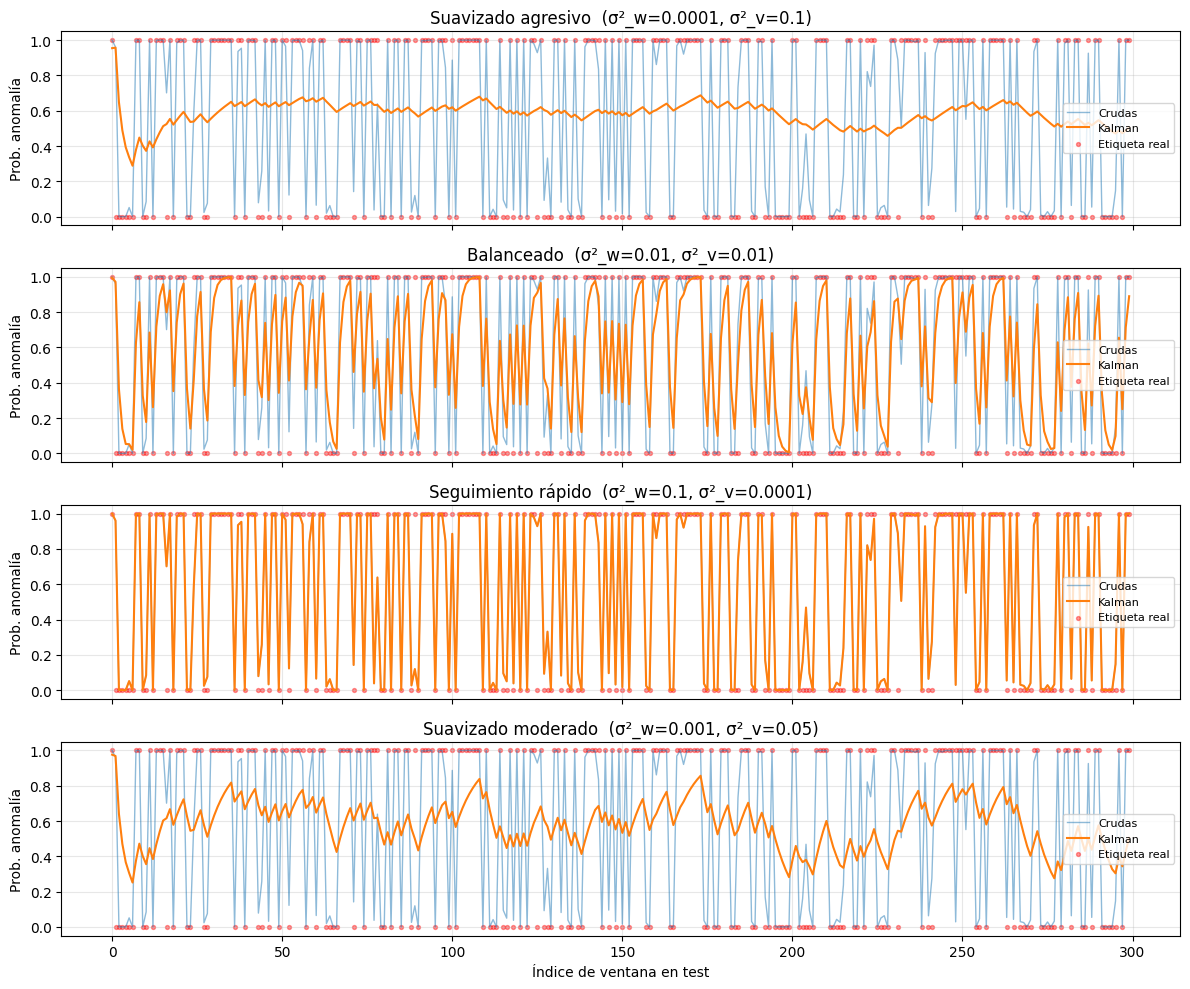

In [13]:
import matplotlib.pyplot as plt

# Tomamos un fragmento representativo
inicio, fin = 0, 300
fragmento = slice(inicio, fin)

fig, axes = plt.subplots(len(kalman_configurate), 1,
                          figsize=(12, 2.5 * len(kalman_configurate)),
                          sharex=True)

for ax, (sigma2_w, sigma2_v, description) in zip(axes, kalman_configurate):
    key = f"σ²_w={sigma2_w}, σ²_v={sigma2_v}"
    probs_s = kalman_results[key]['probs_suavizadas']

    ax.plot(probs_crudas[fragmento], label='Crudas', alpha=0.5, linewidth=1)
    ax.plot(probs_s[fragmento], label='Kalman', linewidth=1.5)
    ax.scatter(np.arange(fin - inicio), etiquetas_test[fragmento],
               color='red', s=8, alpha=0.4, label='Etiqueta real')
    ax.set_title(f"{description}  ({key})")
    ax.set_ylabel('Prob. anomalía')
    ax.set_ylim(-0.05, 1.05)
    ax.legend(loc='center right', fontsize=8)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Índice de ventana en test')
plt.tight_layout()
plt.show()